In [1]:
%load_ext autoreload
%autoreload 2

import ibl_info.measures.information_measures as measures

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import timeit

In [3]:
source_a = np.random.randint(0, 3, 5000)
source_b = np.random.randint(0, 3, 5000)

In [4]:
marginal_x = measures.compute_probability_distribution(source_a)
marginal_y = measures.compute_probability_distribution(source_b)

In [5]:
joint = measures.compute_probability_distribution(source_a, source_b)

In [6]:
marginal_x, marginal_y

({np.int64(1): 0.3186, np.int64(2): 0.337, np.int64(0): 0.3444},
 {np.int64(1): 0.341, np.int64(2): 0.3254, np.int64(0): 0.3336})

In [7]:
measures.mi_plugin(source_a, source_b)

np.float64(0.0008983154810106348)

In [4]:
from scipy.stats import entropy
from ibl_info.measures.broja_pid import MI

/Users/kschille/micromamba/envs/info-decom/lib/python3.12/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [5]:
entropy(list(joint.values()), base=2) - measures.entropy(joint) < 1e-6

NameError: name 'joint' is not defined

In [10]:
MI(source_a, source_a) - measures.mi_plugin(source_a, source_a) < 1e-6

np.True_

In [6]:
from ibl_info.measures.information_measures import split_data

In [7]:
measures.mi_plugin(source_a, source_b)

np.float64(0.00035589312082005256)

In [8]:
measures.mi_unbiased(
    source_a,
    source_b,
)

np.float64(-0.0018561033690880325)

## MI measures

### Generate dummy data and compute measures

In [14]:
# generate ground truth data and then compute bias measures

nNeurons = 20
nTimepoints = 60
# ms
nTrials = 50

baselineActivity = 0.2
# Baseline activity level
noiseLevel = 0.9
# Level of random noise in baseline activity
stimulus_amplitude = 3
# Increase in activity for stimulus-responsive neurons


stimulus = np.random.randint(0, 2, nTrials)

In [15]:
# choose 1/3 neurons to respond to stimulus

responsive_idx_one = np.random.choice(np.arange(0, 20), 6, replace=False)
remaining_idx = np.setdiff1d(np.arange(0, 20), responsive_idx_one)
responsive_idx_two = np.random.choice(remaining_idx, 6, replace=False)
remaining_idx = np.setdiff1d(remaining_idx, responsive_idx_two)

In [16]:
neural_data = baselineActivity + noiseLevel * np.random.randn(nNeurons, nTimepoints, nTrials)
original_data = neural_data.copy()

In [17]:
def modify_neural_data(
    neural_data, neurons_to_consider, stimulus_amplitude, stimulus, nTrials, nTimepoints, stim_type
):

    for neuron in neurons_to_consider:
        response_window_start = np.random.randint(
            10,
            30,
        )
        response_window_length = np.random.randint(5, 25)
        response_window_end = np.min([response_window_start + response_window_length, nTimepoints])

        for trial_idx in range(0, nTrials):

            if stimulus[trial_idx] == stim_type:
                neural_data[
                    neuron, response_window_start:response_window_end, trial_idx
                ] += stimulus_amplitude
    return neural_data

In [18]:
modifier = modify_neural_data(
    neural_data, responsive_idx_one, stimulus_amplitude, stimulus, nTrials, nTimepoints, 0
)

In [19]:
modifier = modify_neural_data(
    modifier, responsive_idx_two, stimulus_amplitude, stimulus, nTrials, nTimepoints, 1
)

In [20]:
type_one = np.where(stimulus == 0)[0]
type_two = np.where(stimulus == 1)[0]

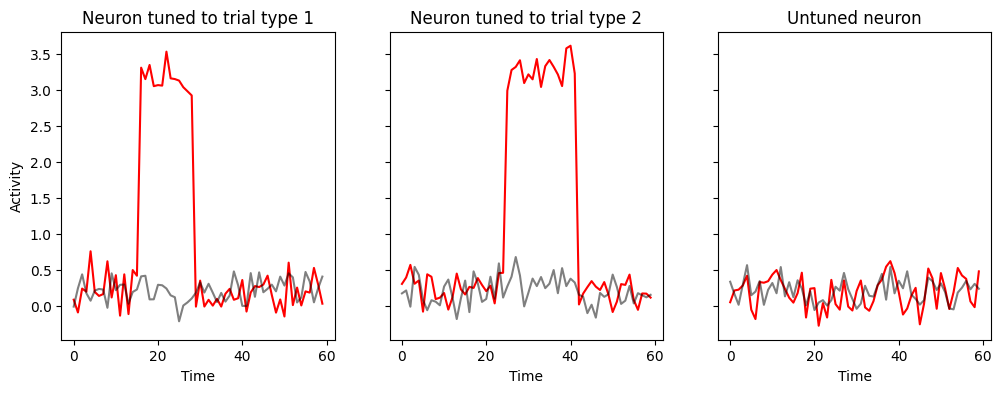

In [22]:
# check visually
one_responsive_neuron = np.mean(modifier[responsive_idx_one[0], :, type_one], axis=0)
one_responsive_neuron_alternate = np.mean(modifier[responsive_idx_one[0], :, type_two], axis=0)

two_responsive_neuron = np.mean(modifier[responsive_idx_two[0], :, type_two], axis=0)
two_responsive_neuron_alternate = np.mean(modifier[responsive_idx_two[0], :, type_one], axis=0)

random_neuron = np.mean(modifier[remaining_idx[0], :, type_one], axis=0)
random_neuron_alt = np.mean(modifier[remaining_idx[0], :, type_two], axis=0)

fig, ax = plt.subplots(figsize=(12, 4), ncols=3, sharey=True)

ax[0].plot(one_responsive_neuron, "r")
ax[0].plot(one_responsive_neuron_alternate, "k", alpha=0.5)

ax[1].plot(two_responsive_neuron, "r")
ax[1].plot(two_responsive_neuron_alternate, "k", alpha=0.5)


ax[2].plot(random_neuron, "r")
ax[2].plot(random_neuron_alt, "k", alpha=0.5)

ax[0].set_title("Neuron tuned to trial type 1")
ax[1].set_title("Neuron tuned to trial type 2")
ax[2].set_title("Untuned neuron")
ax[0].set_ylabel("Activity")

for idx in range(3):
    ax[idx].set_xlabel("Time")

In [23]:
# use my binning procedure, then compute the mi for these particular neurons

In [23]:
from decision_rnn.information_measures.processing import (
    equipopulated_binning,
    hidden_layer_binning_equipopulated,
)
from decision_rnn.analysis.congruent_information_analysis import discretize_all_timesteps

In [24]:
neuron_a = modifier[responsive_idx_one[0], :].transpose(1, 0)
neuron_b = modifier[responsive_idx_two[0], :].transpose(1, 0)
neuron_random = modifier[remaining_idx[0], :].transpose(1, 0)

In [25]:
def look_at_neuron(neuron, response, noresponse, n_bins=10, title="title"):

    neuron_discretized = equipopulated_binning(
        neuron.reshape(
            -1,
        ),
        n_bins=n_bins,
    ).reshape(neuron.shape)

    neuron_response = neuron[response, :]
    neuron_noresponse = neuron[noresponse, :]

    neuron_discretized_response = neuron_discretized[response, :]
    neuron_discretized_noresponse = neuron_discretized[noresponse, :]

    # plot that
    fig, ax = plt.subplots(ncols=2, figsize=(8, 4))
    ax[0].plot(np.mean(neuron_response, axis=0))
    ax[0].plot(np.mean(neuron_noresponse, axis=0))
    ax[0].set_title("Neural response")

    ax[1].plot(np.mean(neuron_discretized_response, axis=0))
    ax[1].plot(np.mean(neuron_discretized_noresponse, axis=0))
    ax[1].set_title("Binned response")

    # compute mi
    ntimepoints = neuron.shape[-1]
    mutual_information_neuron = np.zeros((3, ntimepoints))

    for idx in range(ntimepoints):
        mutual_information_neuron[0, idx] = measures.corrected_mutual_information(  # type: ignore
            source=stimulus, target=neuron_discretized[:, idx]
        )
        mutual_information_neuron[1, idx] = measures.corrected_mutual_information(  # type: ignore
            source=stimulus, target=neuron_discretized[:, idx], unbiased_measure="quadratic"
        )
        mutual_information_neuron[2, idx] = measures.corrected_mutual_information(  # type: ignore
            source=stimulus, target=neuron_discretized[:, idx], unbiased_measure="linear"
        )

    # plot this
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(mutual_information_neuron[0, :], label="plugin", color="k")
    ax.plot(mutual_information_neuron[1, :], label="qe", color="red", alpha=0.75)
    ax.plot(mutual_information_neuron[2, :], label="le", color="blue", alpha=0.75)
    ax.set_title(f"{title}")
    plt.legend()

In [26]:
from decision_rnn.information_measures.processing import equipopulated_binning

### Sample neurons

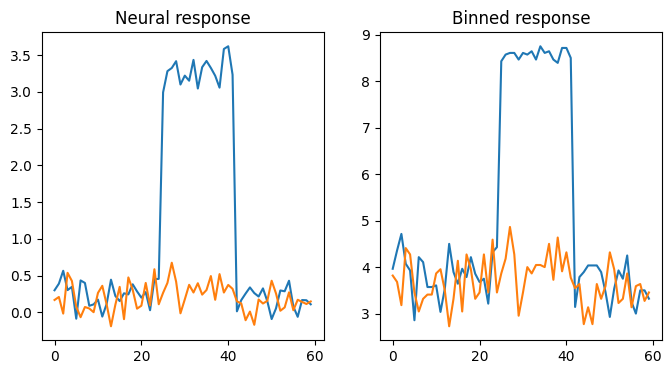

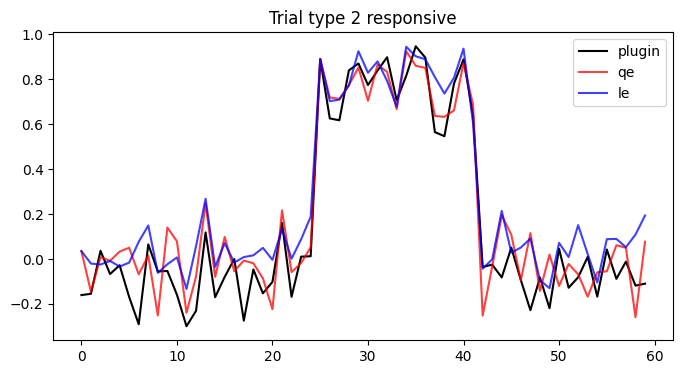

In [27]:
look_at_neuron(neuron_b, type_two, type_one, title="Trial type 2 responsive")

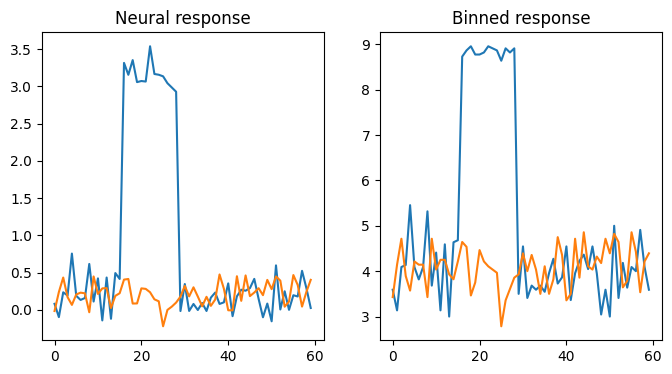

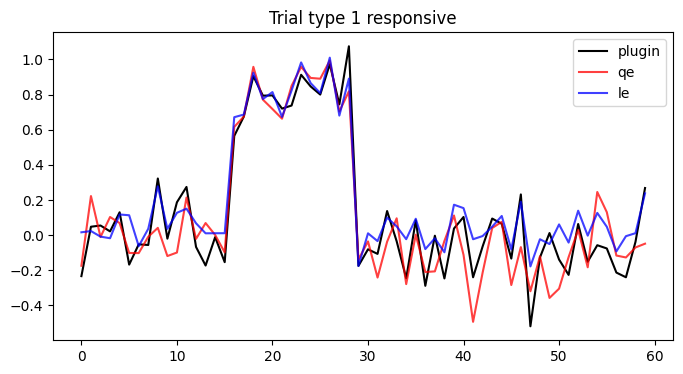

In [28]:
look_at_neuron(neuron_a, type_one, type_two, title="Trial type 1 responsive")

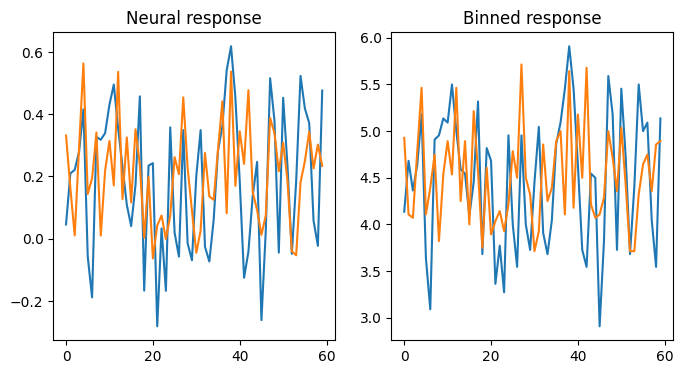

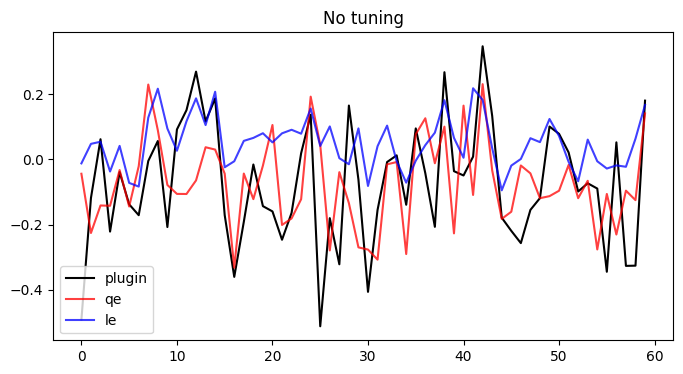

In [29]:
look_at_neuron(neuron_random, type_one, type_two, title="No tuning")

In [98]:
# nice, the mi works, also with plugin methods
# n_binsize=10 for real data

## PID Measures

### generate dummy data

In [9]:
# generate synergistic neurons
# spiking is dependent on cross-correlations

nNeurons = 20
nPairs = nNeurons * (nNeurons - 1) / 2
nTrials_per_stim = 200
nShuff = 2
nReps = 10
tPoints = 500

In [10]:
def generate_poission_spikes(time, rate, noise_prob):
    time = np.asarray(time)

    dt = time[1] - time[0]

    if np.isscalar(rate):
        rate = rate * np.ones_like(time)

    spikes = np.zeros_like(time, dtype=int)
    rand_nums = np.random.uniform(0, 1, size=time.shape)
    spikes[rand_nums <= dt * rate] = 1

    if noise_prob != 0:
        rand_nums_noise = np.random.uniform(0, 1, size=time.shape)
        spikes[rand_nums_noise <= noise_prob] = ~spikes[rand_nums_noise <= noise_prob]
    return spikes

In [11]:
def simulate_spike_trains(
    number_of_neurons,
    timepoints,
    ntrials_per_stimulus,
    lambda1,
    lambda2,
    lambda1_noise,
    lambda2_noise,
    gen_parameter="nonoise",
):

    response_stim_one = np.zeros((number_of_neurons, timepoints, ntrials_per_stimulus))
    response_stim_two = np.zeros((number_of_neurons, timepoints, ntrials_per_stimulus))
    if gen_parameter == "nonoise":

        for neuron in range(number_of_neurons):
            for trials in range(ntrials_per_stimulus):
                response_stim_one[neuron, :, trials] = generate_poission_spikes(
                    np.arange(timepoints), lambda1 / timepoints, 0
                )
                response_stim_two[neuron, :, trials] = generate_poission_spikes(
                    np.arange(timepoints), lambda2 / timepoints, 0
                )
    else:
        for trials in range(ntrials_per_stimulus):
            spikes1_noise = generate_poission_spikes(
                np.arange(timepoints), lambda1_noise / timepoints, 0
            )
            if gen_parameter == "limitnoise":
                spikes2_noise = generate_poission_spikes(
                    np.arange(timepoints), lambda2_noise / timepoints, 0
                )

            for neuron in range(number_of_neurons):
                spikes1 = generate_poission_spikes(np.arange(timepoints), lambda1 / timepoints, 0)
                spikes2 = generate_poission_spikes(np.arange(timepoints), lambda2 / timepoints, 0)
                response_stim_one[neuron, :, trials] = spikes1 + spikes1_noise
                if gen_parameter == "limitnoise":
                    response_stim_two[neuron, :, trials] = spikes2 + spikes2_noise
                else:
                    response_stim_two[neuron, :, trials] = spikes2

    return response_stim_one, response_stim_two

In [ ]:
nNeurons = 20
nPairs = nNeurons * (nNeurons - 1) / 2
nTrials_per_stim = 200
nShuff = 2
nReps = 10
tPoints = 500


# these parameters are for limiting correlations
lambda_1 = 0.8
lambda_2 = 1.9
lambda_noise_1 = 0.2
lambda_noise_2 = 0.1

stimulus = np.concatenate([np.zeros((nTrials_per_stim)), np.ones((nTrials_per_stim))])

r1_caseone, r2_caseone = simulate_spike_trains(
    number_of_neurons=nNeurons,
    timepoints=tPoints,
    ntrials_per_stimulus=nTrials_per_stim,
    lambda1=lambda_1,
    lambda1_noise=lambda_noise_1,
    lambda2=lambda_2,
    lambda2_noise=lambda_noise_2,
    gen_parameter="nonoise",
)

# these parameters are for enhancing correlations
lambda_1 = 1
lambda_2 = 2
lambda_noise_1 = 1
lambda_noise_2 = 0

r1_casetwo, r2_casetwo = simulate_spike_trains(
    number_of_neurons=nNeurons,
    timepoints=tPoints,
    ntrials_per_stimulus=nTrials_per_stim,
    lambda1=lambda_1,
    lambda1_noise=lambda_noise_1,
    lambda2=lambda_2,
    lambda2_noise=lambda_noise_2,
    gen_parameter="limitnoise",
)



In [13]:
# total spike count for each trial
r1_caseone_over_time = np.sum(r1_caseone, axis=1)
r2_caseone_over_time = np.sum(r2_caseone, axis=1)

r1_casetwo_over_time = np.sum(r1_casetwo, axis=1)
r2_casetwo_over_time = np.sum(r2_casetwo, axis=1)

# just combine

case_one = np.hstack([r1_caseone_over_time, r2_caseone_over_time])
case_two = np.hstack([r1_casetwo_over_time, r2_casetwo_over_time])

In [14]:
# now if we want to compute pid; then what
# generate pairs
import itertools


def generate_source_ids(number_of_neurons):
    combinations_neuronids = []
    for x in itertools.combinations(range(number_of_neurons), 2):
        combinations_neuronids.append([x[0], x[1]])

    combinations_neuronids = np.asarray(combinations_neuronids)
    return combinations_neuronids

In [15]:
sources = generate_source_ids(20)

In [16]:
from tqdm import tqdm

In [35]:
from ibl_info.measures.information_measures import pid_plugin


def temp_unbiased(source_a, source_b, target, repeats=1):

    # very similiar to mutual information computation
    n_trials = len(target)
    n_partitions = np.asarray([1, 2, 4])
    pid_array = np.zeros((len(n_partitions), 4))
    pid_unbiased = np.zeros((4))
    # for complete data, i/e, Iplugin
    pid_array[0, :] = pid_plugin(source_a, source_b, target)

    # i'll just do this subsampling once, maybe we should do it more times
    for rxs in range(0, repeats):
        for idx in range(1, len(n_partitions)):

            splits = n_partitions[idx]
            # split data splits the data into equal number of splits
            y_part, x1_part, x2_part = split_data(  # type: ignore
                target=target, sourcea=source_a, sourceb=source_b, splits=splits
            )
            for parts in range(0, splits):
                y_temp = y_part[parts]
                x1_temp = x1_part[parts]
                x2_temp = x2_part[parts]
                # now what
                pid_temp = pid_plugin(source_a=x1_temp, source_b=x2_temp, target=y_temp)
                if splits == 2:
                    pid_array[idx, :] = pid_array[idx, :] + pid_temp / 2
                elif splits == 4:
                    pid_array[idx, :] = pid_array[idx, :] + pid_temp / 4

    # should have 3 pids completely ready
    # now to run polyfit, etc

    x_extrap = n_partitions / n_trials

    # for each column of pid_array, fit an equation:
    params = np.zeros((4, 3))  # since QE
    for idx in range(0, 4):
        values = pid_array[:, idx]  # 0 is U1, 1 is U2, 2 is SI and 3 is CI
        params[idx, :] = np.polyfit(x_extrap, values, 2)
        pid_unbiased[idx] = (
            params[idx, 2] / repeats
        )  # NOTE: divide here when we do more repetations

    return pid_unbiased, pid_array, params, x_extrap

In [36]:
def compute_pid(sources, data, targets, unbiased_measure="quadratic"):
    pid_information = np.zeros((len(sources), 4))  # neuronsC2 x 4
    for idx in tqdm(
        range(len(sources)), desc="Running for all sources", leave=False
    ):  # this is the place to introduce parallelization
        s1 = sources[idx][0]
        s2 = sources[idx][1]
        X1 = np.asarray(data[s1, :], dtype=np.int32)
        X2 = np.asarray(data[s2, :], dtype=np.int32)
        Y = np.asarray(targets, dtype=np.int32)
        u1, u2, red, syn = temp_unbiased(sourcea=X1, sourceb=X2, target=Y)  # type: ignore
        pid_information[idx, :] = u1, u2, red, syn

    return pid_information

In [18]:
case_one.shape

(20, 400)

In [81]:
def plot_all_corrections(sources, data, targets):

    for idx in tqdm(
        range(len(sources)), desc="Running for all sources", leave=False
    ):  # this is the place to introduce parallelization
        s1 = sources[idx][0]
        s2 = sources[idx][1]
        X1 = np.asarray(data[s1, :], dtype=np.int32)
        X2 = np.asarray(data[s2, :], dtype=np.int32)
        Y = np.asarray(targets, dtype=np.int32)

        pid_unbiased, pid_array, params, x_extrap = temp_unbiased(source_a=X1, source_b=X2, target=Y)  # type: ignore

        fig, ax = plt.subplots(figsize=(16, 4), ncols=4)
        labels = ["U1", "U2", "Red", "Syn"]
        for idx in range(4):
            x_fit = np.linspace(x_extrap.min(), x_extrap.max(), 100)
            y_fit = np.polyval(params[idx, :], x_fit)
            ax[idx].plot(x_fit, y_fit, "-.")
            ax[idx].plot(x_extrap, pid_array[:, idx], "ro")
            ax[idx].scatter(0, pid_unbiased[idx], marker="o", color="k")
            ax[idx].scatter(0, params[idx, 2], marker="o", color="r", s=5)
            ax[idx].set_title(f"Fit for {labels[idx]}")
            ax[idx].spines["right"].set_visible(False)
            ax[idx].spines["top"].set_visible(False)
            ax[idx].set_xticks(
                np.concatenate([[0], x_extrap]), labels=["corrected", "N", "N/2", "N/4"]
            )
        plt.suptitle(f"PID for {s1} and {s2}")

In [82]:
sources = generate_source_ids(3)

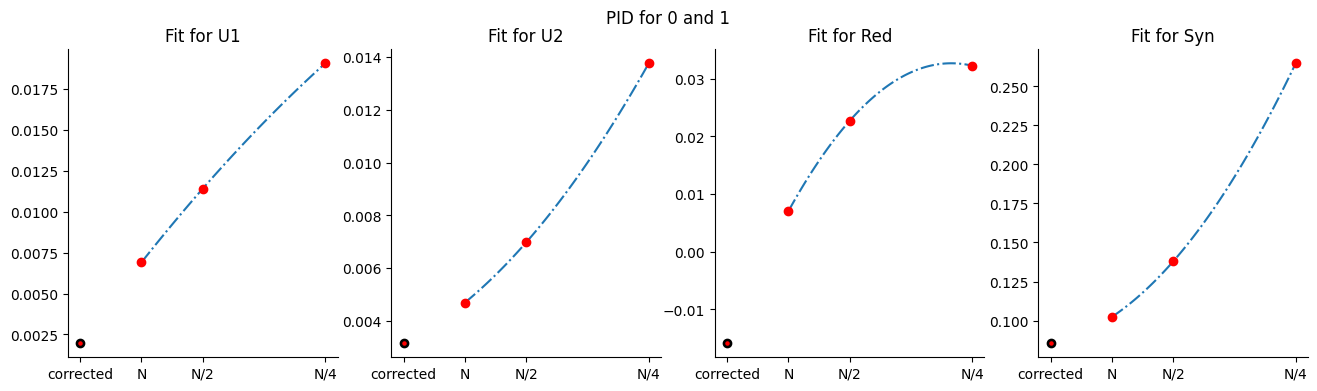

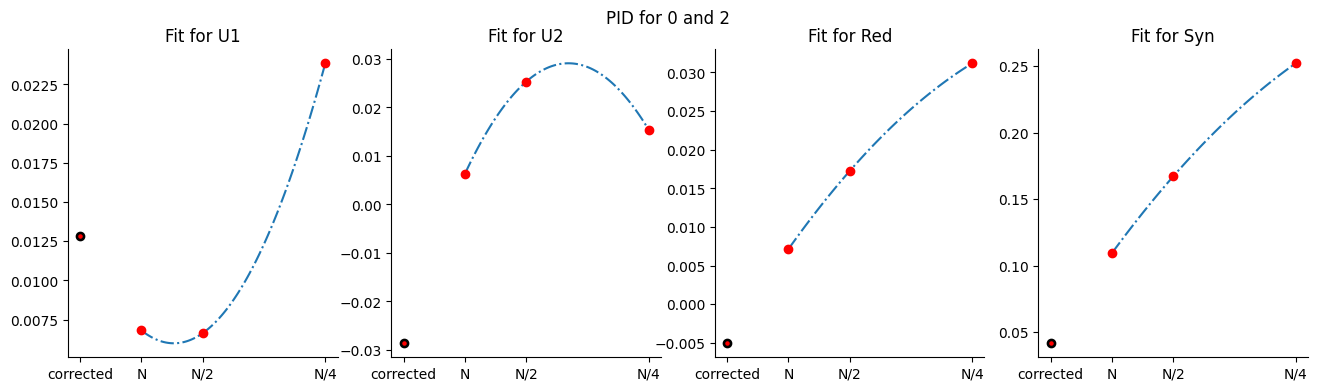

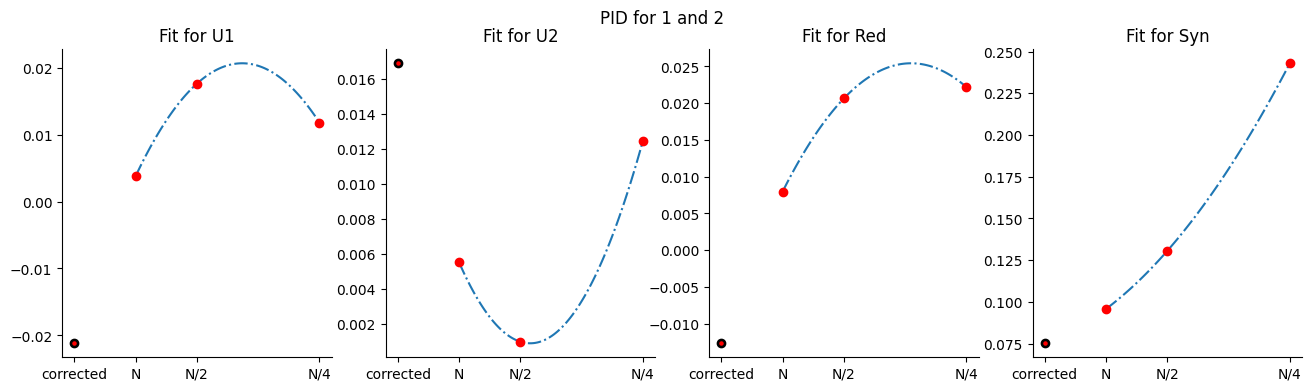

In [83]:
plot_all_corrections(sources, case_two, stimulus)

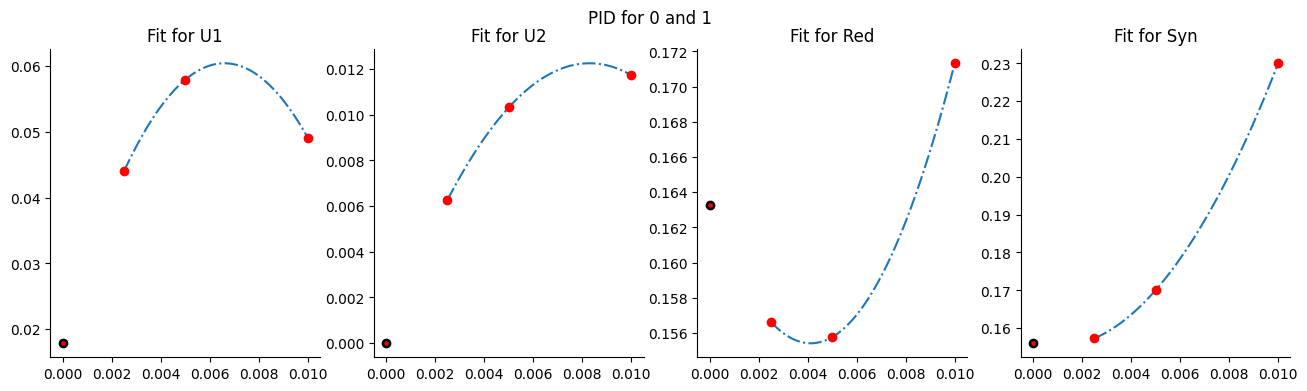

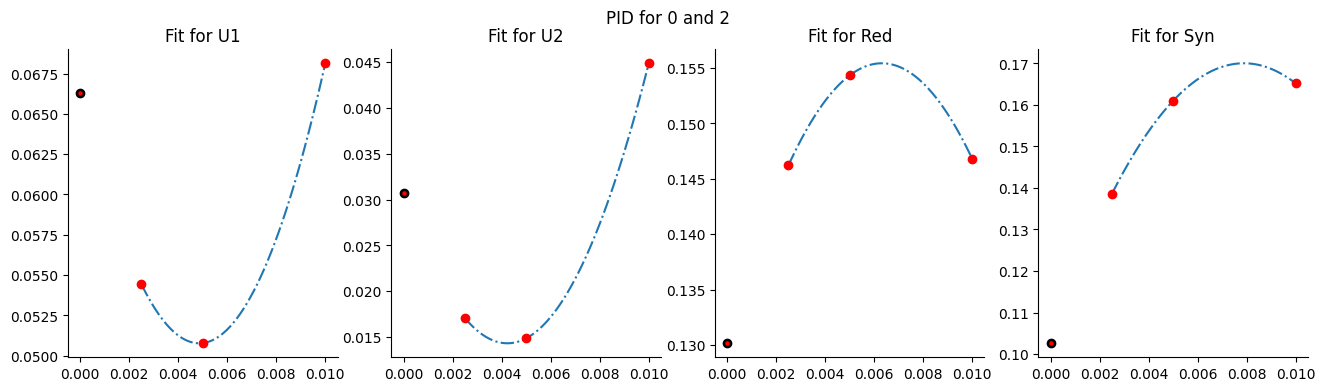

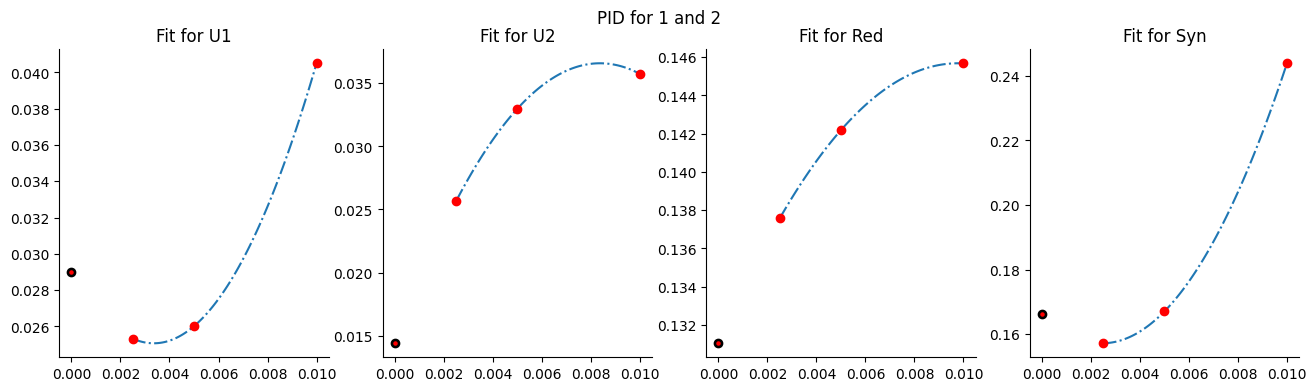

In [77]:
plot_all_corrections(sources, case_one, stimulus)

### plots

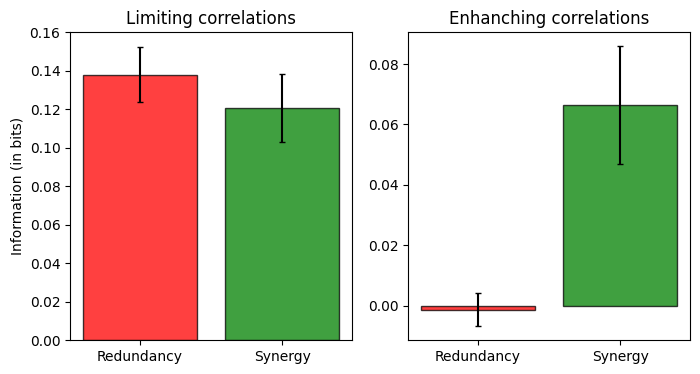

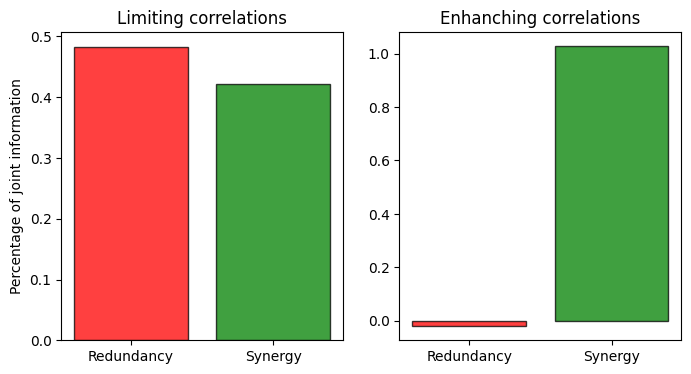

In [47]:
qe_pids_case_one = compute_pid(sources, data=case_one, targets=stimulus)
qe_pids_case_two = compute_pid(sources, data=case_two, targets=stimulus)

means_case_one = np.mean(qe_pids_case_one, axis=0)
stds_case_one = np.std(qe_pids_case_one, axis=0)


means_case_two = np.mean(qe_pids_case_two, axis=0)
stds_case_two = np.std(qe_pids_case_two, axis=0)

fig, ax = plt.subplots(figsize=(8, 4), ncols=2, sharex=True)

ax[0].bar(
    np.arange(2),
    means_case_one[2:],
    yerr=stds_case_one[2:] / 2,
    capsize=2,
    color=["red", "green"],
    alpha=0.75,
    edgecolor="k",
)
ax[1].bar(
    np.arange(2),
    means_case_two[2:],
    yerr=stds_case_two[2:] / 2,
    capsize=2,
    color=["red", "green"],
    alpha=0.75,
    edgecolor="k",
)

ax[0].set_ylabel("Information (in bits)")
ax[0].set_title("Limiting correlations")
ax[1].set_title("Enhanching correlations")
ax[0].set_xticks(np.arange(2), ["Redundancy", "Synergy"])

# percentage of joint information

percentages_case_one = means_case_one / np.sum(means_case_one)
percentages_case_two = means_case_two / np.sum(means_case_two)

fig, ax = plt.subplots(figsize=(8, 4), ncols=2, sharex=True)

ax[0].bar(
    np.arange(2),
    percentages_case_one[2:],
    color=["red", "green"],
    alpha=0.75,
    edgecolor="k",
)
ax[1].bar(
    np.arange(2),
    percentages_case_two[2:],
    color=["red", "green"],
    alpha=0.75,
    edgecolor="k",
)

ax[0].set_ylabel("Percentage of joint information")
ax[0].set_title("Limiting correlations")
ax[1].set_title("Enhanching correlations")
ax[0].set_xticks(np.arange(2), ["Redundancy", "Synergy"])